# CASALS L1B single-sweep waveform viewer

This notebook does only three things:

1. Read one CASALS L1B H5 file.
2. Display the RX waveform intensity image for one sweep, with tracks on the x-axis and RX bins on the y-axis.
3. Display the complete TX and RX waveforms for one selected track in that sweep, with the official `refh` location marked on the RX waveform when a strict bin location can be identified.

No smoothing, peak detection, decomposition, filtering, or classification is performed.


In [63]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Optional

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline


# --------------------------------------------------------------------------------------
# User configuration
# --------------------------------------------------------------------------------------
# The default path follows the usual CASALS_L1B/notebooks layout.
# Change this to your H5 file.
H5_PATH = Path("../casals_h5_downloads/casals_l1b_20241118T171757_001_02.h5")


# RX image mode:
#   "raw_minus_bg_mean": plot raw RX waveform minus per-pulse bg_mean. This is the
#                        recommended mode for a diverging RdBu_r image centered at 0.
#   "raw":              plot raw RX waveform values directly.
RX_IMAGE_VALUE_MODE = "raw_minus_bg_mean"

# Display range controls for the RX image.
# If RX_DISPLAY_ABS_MAX is not None, use [-RX_DISPLAY_ABS_MAX, +RX_DISPLAY_ABS_MAX].
# Otherwise use RX_DISPLAY_VMIN / RX_DISPLAY_VMAX if provided.
# If all are None, use a robust symmetric percentile range around zero.
RX_DISPLAY_ABS_MAX: Optional[float] = None
RX_DISPLAY_VMIN: Optional[float] = None
RX_DISPLAY_VMAX: Optional[float] = None
RX_ROBUST_PERCENTILE = 99.0

# If True, the RX waveform plot raises an error unless a strict official refh bin can
# be identified from an explicit refh-bin dataset or a unique refh_amp match in raw RX.
REQUIRE_STRICT_REFH_BIN = True

# Tolerances for strict matching of `refh_amp` to a raw RX waveform sample.
REFH_AMP_ABS_TOL = 1e-6
REFH_AMP_REL_TOL = 1e-7

# Figure settings.
FIG_DPI = 130


## Helper functions

In [64]:
def list_h5_datasets(h5: h5py.File) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    def visitor(name: str, obj: Any) -> None:
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": name,
                "basename": Path(name).name,
                "shape": tuple(obj.shape),
                "dtype": str(obj.dtype),
            })

    h5.visititems(visitor)
    return pd.DataFrame(rows).sort_values("path").reset_index(drop=True)


def find_dataset_path(h5: h5py.File, candidates: list[str], required: bool = True) -> Optional[str]:
    """Find a dataset by exact H5 path or by basename."""
    dataset_table = list_h5_datasets(h5)
    basenames = {str(row.basename): str(row.path) for row in dataset_table.itertuples(index=False)}

    for name in candidates:
        if name in h5 and isinstance(h5[name], h5py.Dataset):
            return name
        if name in basenames:
            return basenames[name]

    if required:
        raise KeyError(f"Could not find any dataset from candidates: {candidates}")
    return None


def require_dataset(h5: h5py.File, candidates: list[str]) -> h5py.Dataset:
    path = find_dataset_path(h5, candidates, required=True)
    assert path is not None
    return h5[path]


def read_optional_vector(
    h5: h5py.File,
    candidates: list[str],
    n_records: int,
    dtype: Any = np.float64,
) -> tuple[Optional[np.ndarray], Optional[str]]:
    path = find_dataset_path(h5, candidates, required=False)
    if path is None:
        return None, None
    arr = np.asarray(h5[path][...]).reshape(-1)
    if arr.size != n_records:
        raise ValueError(f"Dataset {path} has size {arr.size:,}, expected {n_records:,}.")
    return arr.astype(dtype, copy=False), path


def infer_record_axis(ds: h5py.Dataset, n_records: int) -> int:
    """Return 0 if waveform dataset is records x bins; return 1 if bins x records."""
    if ds.ndim != 2:
        raise ValueError(f"Waveform dataset must be 2D; got shape {ds.shape}.")
    if int(ds.shape[0]) == int(n_records):
        return 0
    if int(ds.shape[1]) == int(n_records):
        return 1
    raise ValueError(
        f"Could not infer record axis for waveform shape {ds.shape}; "
        f"expected one axis to equal n_records={n_records:,}."
    )


def waveform_bin_count(ds: h5py.Dataset, record_axis: int) -> int:
    return int(ds.shape[1] if record_axis == 0 else ds.shape[0])


def read_one_waveform(ds: h5py.Dataset, record_axis: int, record_index: int) -> np.ndarray:
    if record_axis == 0:
        return np.asarray(ds[int(record_index), :], dtype=np.float32)
    return np.asarray(ds[:, int(record_index)], dtype=np.float32)


def read_waveform_matrix(
    ds: h5py.Dataset,
    record_axis: int,
    record_indices_by_track: np.ndarray,
) -> np.ndarray:
    n_tracks = int(record_indices_by_track.size)
    n_bins = waveform_bin_count(ds, record_axis)
    matrix = np.full((n_tracks, n_bins), np.nan, dtype=np.float32)
    for row, record_index in enumerate(record_indices_by_track):
        if int(record_index) < 0:
            continue
        matrix[row, :] = read_one_waveform(ds, record_axis, int(record_index))
    return matrix


def build_sweep_track_records(
    sweep_num: np.ndarray,
    track_num: np.ndarray,
    sweep_value: int,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Return:
      track_axis_values: displayed track values.
      record_indices_by_track: record index for each displayed track value, or -1 if missing.
      duplicate_records: rows for duplicate track entries in this sweep.
    """
    sweep_num = np.asarray(sweep_num)
    track_num = np.asarray(track_num)

    if sweep_num.shape != track_num.shape:
        raise ValueError(f"sweep_num and track_num shapes differ: {sweep_num.shape} vs {track_num.shape}")

    in_sweep = sweep_num == sweep_value
    if not np.any(in_sweep):
        available = np.unique(sweep_num)
        raise ValueError(
            f"SWEEP_INDEX={sweep_value} was not found. "
            f"Available sweep range appears to be {available.min()}..{available.max()}."
        )

    sweep_records = np.flatnonzero(in_sweep)
    sweep_tracks = track_num[in_sweep].astype(int)

    # For CASALS L1B, track values are expected to be 0..255. Keep the full contiguous
    # axis when possible so the image is consistently 256 columns.
    min_track = int(np.nanmin(track_num))
    max_track = int(np.nanmax(track_num))
    if min_track >= 0 and max_track <= 4096:
        track_axis_values = np.arange(max_track + 1, dtype=int)
    else:
        track_axis_values = np.sort(np.unique(track_num.astype(int)))

    record_indices_by_track = np.full(track_axis_values.shape[0], -1, dtype=np.int64)
    track_to_row = {int(t): i for i, t in enumerate(track_axis_values)}

    rows: list[dict[str, Any]] = []
    seen: dict[int, int] = {}
    for record_index, t in zip(sweep_records, sweep_tracks):
        t = int(t)
        if t not in track_to_row:
            continue
        if t in seen:
            rows.append({"track_num": t, "first_record_index": seen[t], "duplicate_record_index": int(record_index)})
            continue
        seen[t] = int(record_index)
        record_indices_by_track[track_to_row[t]] = int(record_index)

    duplicate_records = pd.DataFrame(rows)
    return track_axis_values, record_indices_by_track, duplicate_records


def read_bin_axis(h5: h5py.File, candidates: list[str], n_bins: int) -> tuple[np.ndarray, Optional[str]]:
    path = find_dataset_path(h5, candidates, required=False)
    if path is None:
        return np.arange(n_bins, dtype=np.int64), None
    arr = np.asarray(h5[path][...]).reshape(-1)
    if arr.size != n_bins:
        raise ValueError(f"Bin-axis dataset {path} has size {arr.size}, expected {n_bins}.")
    return arr, path


def robust_symmetric_limits(values: np.ndarray, percentile: float) -> tuple[float, float]:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        raise ValueError("Cannot determine display limits from an all-NaN array.")
    vmax = float(np.nanpercentile(np.abs(arr), float(percentile)))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = float(np.nanmax(np.abs(arr)))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    return -vmax, vmax


def resolve_display_limits(values: np.ndarray) -> tuple[float, float]:
    if RX_DISPLAY_ABS_MAX is not None:
        vmax = float(RX_DISPLAY_ABS_MAX)
        if not np.isfinite(vmax) or vmax <= 0:
            raise ValueError("RX_DISPLAY_ABS_MAX must be a positive finite number.")
        return -vmax, vmax

    if RX_DISPLAY_VMIN is not None and RX_DISPLAY_VMAX is not None:
        vmin = float(RX_DISPLAY_VMIN)
        vmax = float(RX_DISPLAY_VMAX)
        if not (np.isfinite(vmin) and np.isfinite(vmax) and vmin < vmax):
            raise ValueError("RX_DISPLAY_VMIN and RX_DISPLAY_VMAX must be finite and vmin < vmax.")
        if not (vmin <= 0 <= vmax):
            raise ValueError("For a zero-centered RdBu_r display, the range must include 0.")
        return vmin, vmax

    return robust_symmetric_limits(values, RX_ROBUST_PERCENTILE)


def safe_numeric(value: Any) -> float:
    try:
        return float(value)
    except Exception:
        return float("nan")


## Read one sweep

In [65]:
H5_PATH = Path(H5_PATH)
if not H5_PATH.exists():
    raise FileNotFoundError(f"H5 file not found: {H5_PATH.resolve()}")

with h5py.File(H5_PATH, "r") as h5:
    rx_ds = require_dataset(h5, ["rx_waveform"])
    tx_ds = require_dataset(h5, ["tx_waveform"])

    sweep_num = np.asarray(require_dataset(h5, ["sweep_num"])[...]).reshape(-1)
    track_num = np.asarray(require_dataset(h5, ["track_num"])[...]).reshape(-1)
    n_records = int(sweep_num.size)
    if track_num.size != n_records:
        raise ValueError(f"track_num size {track_num.size:,} differs from sweep_num size {n_records:,}.")

    rx_record_axis = infer_record_axis(rx_ds, n_records)
    tx_record_axis = infer_record_axis(tx_ds, n_records)
    n_rx_bins = waveform_bin_count(rx_ds, rx_record_axis)
    n_tx_bins = waveform_bin_count(tx_ds, tx_record_axis)

    rx_bins, rx_bins_path = read_bin_axis(h5, ["rx_bins", "rx_bin", "rx_bin_index"], n_rx_bins)
    tx_bins, tx_bins_path = read_bin_axis(h5, ["tx_bins", "tx_bin", "tx_bin_index"], n_tx_bins)

    track_axis_values, record_indices_by_track, duplicate_records = build_sweep_track_records(
        sweep_num=sweep_num,
        track_num=track_num,
        sweep_value=int(SWEEP_INDEX),
    )

    rx_matrix_raw = read_waveform_matrix(rx_ds, rx_record_axis, record_indices_by_track)
    tx_matrix_raw = read_waveform_matrix(tx_ds, tx_record_axis, record_indices_by_track)

    refh, refh_path = read_optional_vector(h5, ["refh", "refh_height", "height", "elevation"], n_records)
    refh_amp, refh_amp_path = read_optional_vector(h5, ["refh_amp", "amp", "amplitude"], n_records)
    refh_snr, refh_snr_path = read_optional_vector(h5, ["refh_snr", "snr"], n_records)
    bg_mean, bg_mean_path = read_optional_vector(h5, ["bg_mean", "background_mean"], n_records)
    bg_std, bg_std_path = read_optional_vector(h5, ["bg_std", "background_std"], n_records)

summary = pd.Series({
    "H5 path": str(H5_PATH.resolve()),
    "selected sweep": int(SWEEP_INDEX),
    "selected track": int(TRACK_INDEX),
    "n_records": n_records,
    "rx_waveform_shape": tuple(rx_matrix_raw.shape),
    "tx_waveform_shape": tuple(tx_matrix_raw.shape),
    "n_track_axis_values": int(track_axis_values.size),
    "tracks present in selected sweep": int(np.count_nonzero(record_indices_by_track >= 0)),
    "missing tracks in selected sweep": int(np.count_nonzero(record_indices_by_track < 0)),
    "duplicate track entries in selected sweep": int(len(duplicate_records)),
    "rx_bins_path": rx_bins_path,
    "tx_bins_path": tx_bins_path,
    "refh_path": refh_path,
    "refh_amp_path": refh_amp_path,
    "refh_snr_path": refh_snr_path,
    "bg_mean_path": bg_mean_path,
    "bg_std_path": bg_std_path,
}).to_frame("value")
display(summary)

if not duplicate_records.empty:
    print("[WARN] Duplicate track entries were found in this sweep. The first record per track was used.")
    display(duplicate_records.head(20))


,value
H5 path,C:\Users\zhong267\OneDrive - purdue.edu\Resear...
selected sweep,5000
selected track,80
n_records,3604480
rx_waveform_shape,"(256, 2728)"
tx_waveform_shape,"(256, 80)"
n_track_axis_values,256
tracks present in selected sweep,256
missing tracks in selected sweep,0
duplicate track entries in selected sweep,0


## Sweep RX intensity image

In [66]:
# Sweep value in the H5 `sweep_num` array.
SWEEP_INDEX = 5000

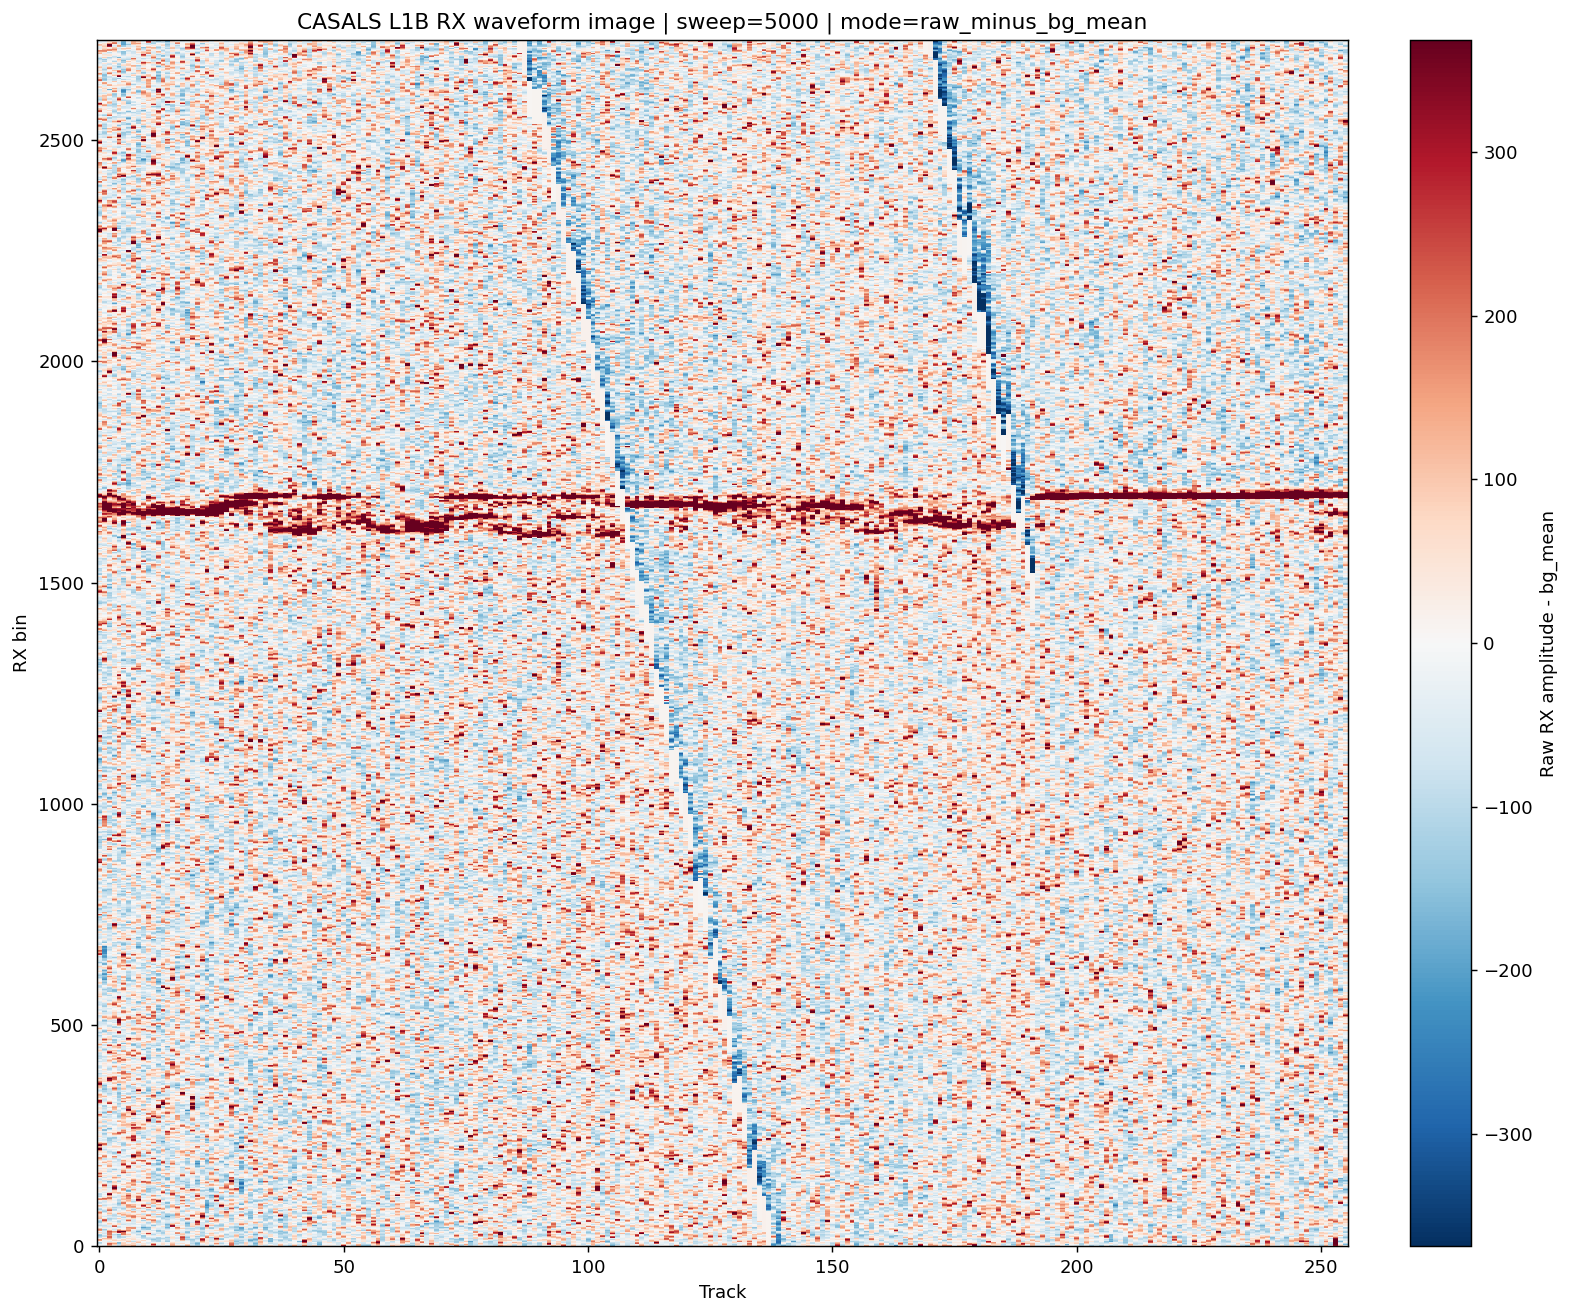

Display range: vmin=-368.538, vcenter=0, vmax=368.538


In [67]:
if RX_IMAGE_VALUE_MODE not in {"raw", "raw_minus_bg_mean"}:
    raise ValueError('RX_IMAGE_VALUE_MODE must be either "raw" or "raw_minus_bg_mean".')

if RX_IMAGE_VALUE_MODE == "raw":
    rx_image = rx_matrix_raw.astype(np.float64)
    colorbar_label = "Raw RX amplitude"
else:
    if bg_mean is None:
        raise KeyError(
            'RX_IMAGE_VALUE_MODE="raw_minus_bg_mean" requires H5 dataset bg_mean. '
            'Set RX_IMAGE_VALUE_MODE="raw" if you want to display raw amplitudes directly.'
        )
    bg_by_track = np.full(track_axis_values.size, np.nan, dtype=np.float64)
    valid_track_rows = record_indices_by_track >= 0
    bg_by_track[valid_track_rows] = bg_mean[record_indices_by_track[valid_track_rows]]
    rx_image = rx_matrix_raw.astype(np.float64) - bg_by_track[:, None]
    colorbar_label = "Raw RX amplitude - bg_mean"

vmin, vmax = resolve_display_limits(rx_image)
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 10), dpi=FIG_DPI, constrained_layout=True)

# Transpose so the figure is approximately RX bins x tracks, i.e., about 2740 x 256.
im = ax.imshow(
    rx_image.T,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    norm=norm,
    extent=[
        float(track_axis_values[0]) - 0.5,
        float(track_axis_values[-1]) + 0.5,
        float(rx_bins[0]),
        float(rx_bins[-1]),
    ],
)

ax.set_title(
    f"CASALS L1B RX waveform image | sweep={SWEEP_INDEX} | mode={RX_IMAGE_VALUE_MODE}"
)
ax.set_xlabel("Track")
ax.set_ylabel("RX bin")
fig.colorbar(im, ax=ax, label=colorbar_label)

plt.show()

print(f"Display range: vmin={vmin:.6g}, vcenter=0, vmax={vmax:.6g}")


## Selected track: complete TX and RX waveforms

In [113]:
# Track value in the H5 `track_num` array, usually 0..255.
TRACK_INDEX = 190
TRACK_COLOR = "magenta"

In [114]:
def get_track_row(track_axis_values: np.ndarray, track_value: int) -> int:
    matches = np.flatnonzero(np.asarray(track_axis_values, dtype=int) == int(track_value))
    if matches.size != 1:
        raise ValueError(f"TRACK_INDEX={track_value} is not in the displayed track axis.")
    return int(matches[0])


def find_explicit_refh_bin_vector(h5: h5py.File, n_records: int) -> tuple[Optional[np.ndarray], Optional[str]]:
    candidates = [
        "refh_bin",
        "refh_bin_index",
        "refh_bin_idx",
        "refh_rx_bin",
        "rx_refh_bin",
        "rx_refh_bin_index",
        "refh_sample",
        "refh_sample_index",
        "max_rx_bin",
        "max_rx_bin_index",
        "rx_peak_bin",
        "rx_peak_bin_index",
    ]
    return read_optional_vector(h5, candidates, n_records, dtype=np.float64)


def strict_refh_bin_from_waveform(
    rx_waveform: np.ndarray,
    record_index: int,
    explicit_refh_bin: Optional[np.ndarray],
    explicit_refh_bin_path: Optional[str],
    refh_amp: Optional[np.ndarray],
) -> dict[str, Any]:
    """
    Determine the official refh bin position without range-window interpolation.

    Strict methods:
      1. explicit H5 refh-bin dataset, if present;
      2. unique raw RX waveform sample matching H5 refh_amp within tight tolerance.

    If no strict method succeeds, the returned status is not_strict.
    """
    rx = np.asarray(rx_waveform, dtype=np.float64)
    out: dict[str, Any] = {
        "status": "not_strict",
        "method": None,
        "bin_index": np.nan,
        "amplitude": np.nan,
        "message": "",
    }

    if explicit_refh_bin is not None:
        raw_bin = safe_numeric(explicit_refh_bin[int(record_index)])
        if np.isfinite(raw_bin):
            bin_index = int(round(raw_bin))
            if 0 <= bin_index < rx.size:
                out.update({
                    "status": "strict",
                    "method": f"explicit_dataset:{explicit_refh_bin_path}",
                    "bin_index": bin_index,
                    "amplitude": float(rx[bin_index]),
                    "message": "Used explicit refh-bin dataset.",
                })
                return out
            out["message"] = f"Explicit refh bin {raw_bin} is outside RX waveform length {rx.size}."

    if refh_amp is not None:
        amp = safe_numeric(refh_amp[int(record_index)])
        if np.isfinite(amp):
            tol = max(float(REFH_AMP_ABS_TOL), float(REFH_AMP_REL_TOL) * max(abs(amp), 1.0))
            matches = np.flatnonzero(np.isfinite(rx) & (np.abs(rx - amp) <= tol))
            if matches.size == 1:
                bin_index = int(matches[0])
                out.update({
                    "status": "strict",
                    "method": f"unique_refh_amp_match:{tol:g}",
                    "bin_index": bin_index,
                    "amplitude": float(rx[bin_index]),
                    "message": "Used the unique raw RX sample matching H5 refh_amp.",
                })
                return out
            if matches.size > 1:
                out["message"] = (
                    f"refh_amp matched {matches.size} RX samples within tolerance {tol:g}; "
                    "there is no unique strict bin."
                )
            else:
                closest = int(np.nanargmin(np.abs(rx - amp)))
                out["message"] = (
                    f"No RX sample matched refh_amp within tolerance {tol:g}. "
                    f"Closest bin={closest}, abs difference={abs(float(rx[closest]) - amp):.6g}."
                )

    if not out["message"]:
        out["message"] = "No explicit refh-bin dataset and no usable refh_amp match were available."
    return out


track_row = get_track_row(track_axis_values, int(TRACK_INDEX))
record_index = int(record_indices_by_track[track_row])
if record_index < 0:
    raise ValueError(f"No waveform record exists for sweep={SWEEP_INDEX}, track={TRACK_INDEX}.")

tx_waveform = tx_matrix_raw[track_row].astype(np.float64)
rx_waveform = rx_matrix_raw[track_row].astype(np.float64)

with h5py.File(H5_PATH, "r") as h5:
    explicit_refh_bin, explicit_refh_bin_path = find_explicit_refh_bin_vector(h5, n_records)

refh_bin_info = strict_refh_bin_from_waveform(
    rx_waveform=rx_waveform,
    record_index=record_index,
    explicit_refh_bin=explicit_refh_bin,
    explicit_refh_bin_path=explicit_refh_bin_path,
    refh_amp=refh_amp,
)

if REQUIRE_STRICT_REFH_BIN and refh_bin_info["status"] != "strict":
    raise RuntimeError(
        "Could not determine a strict official refh bin for the selected waveform. "
        + refh_bin_info["message"]
        + "\nSet REQUIRE_STRICT_REFH_BIN=False only if you intentionally want to view the waveform without a strict refh marker."
    )

selected_meta = pd.Series({
    "sweep": int(SWEEP_INDEX),
    "track": int(TRACK_INDEX),
    "record_index": int(record_index),
    "refh": None if refh is None else safe_numeric(refh[record_index]),
    "refh_amp": None if refh_amp is None else safe_numeric(refh_amp[record_index]),
    "refh_snr": None if refh_snr is None else safe_numeric(refh_snr[record_index]),
    "bg_mean": None if bg_mean is None else safe_numeric(bg_mean[record_index]),
    "bg_std": None if bg_std is None else safe_numeric(bg_std[record_index]),
    "refh_bin_status": refh_bin_info["status"],
    "refh_bin_method": refh_bin_info["method"],
    "refh_bin_index": refh_bin_info["bin_index"],
    "refh_bin_amplitude": refh_bin_info["amplitude"],
    "refh_bin_message": refh_bin_info["message"],
}).to_frame("value")
display(selected_meta)


,value
sweep,5000
track,190
record_index,1280215
refh,170.449886
refh_amp,522.0
refh_snr,2.104564
bg_mean,-33.487268
bg_std,93.839878
refh_bin_status,strict
refh_bin_method,unique_refh_amp_match:5.22e-05


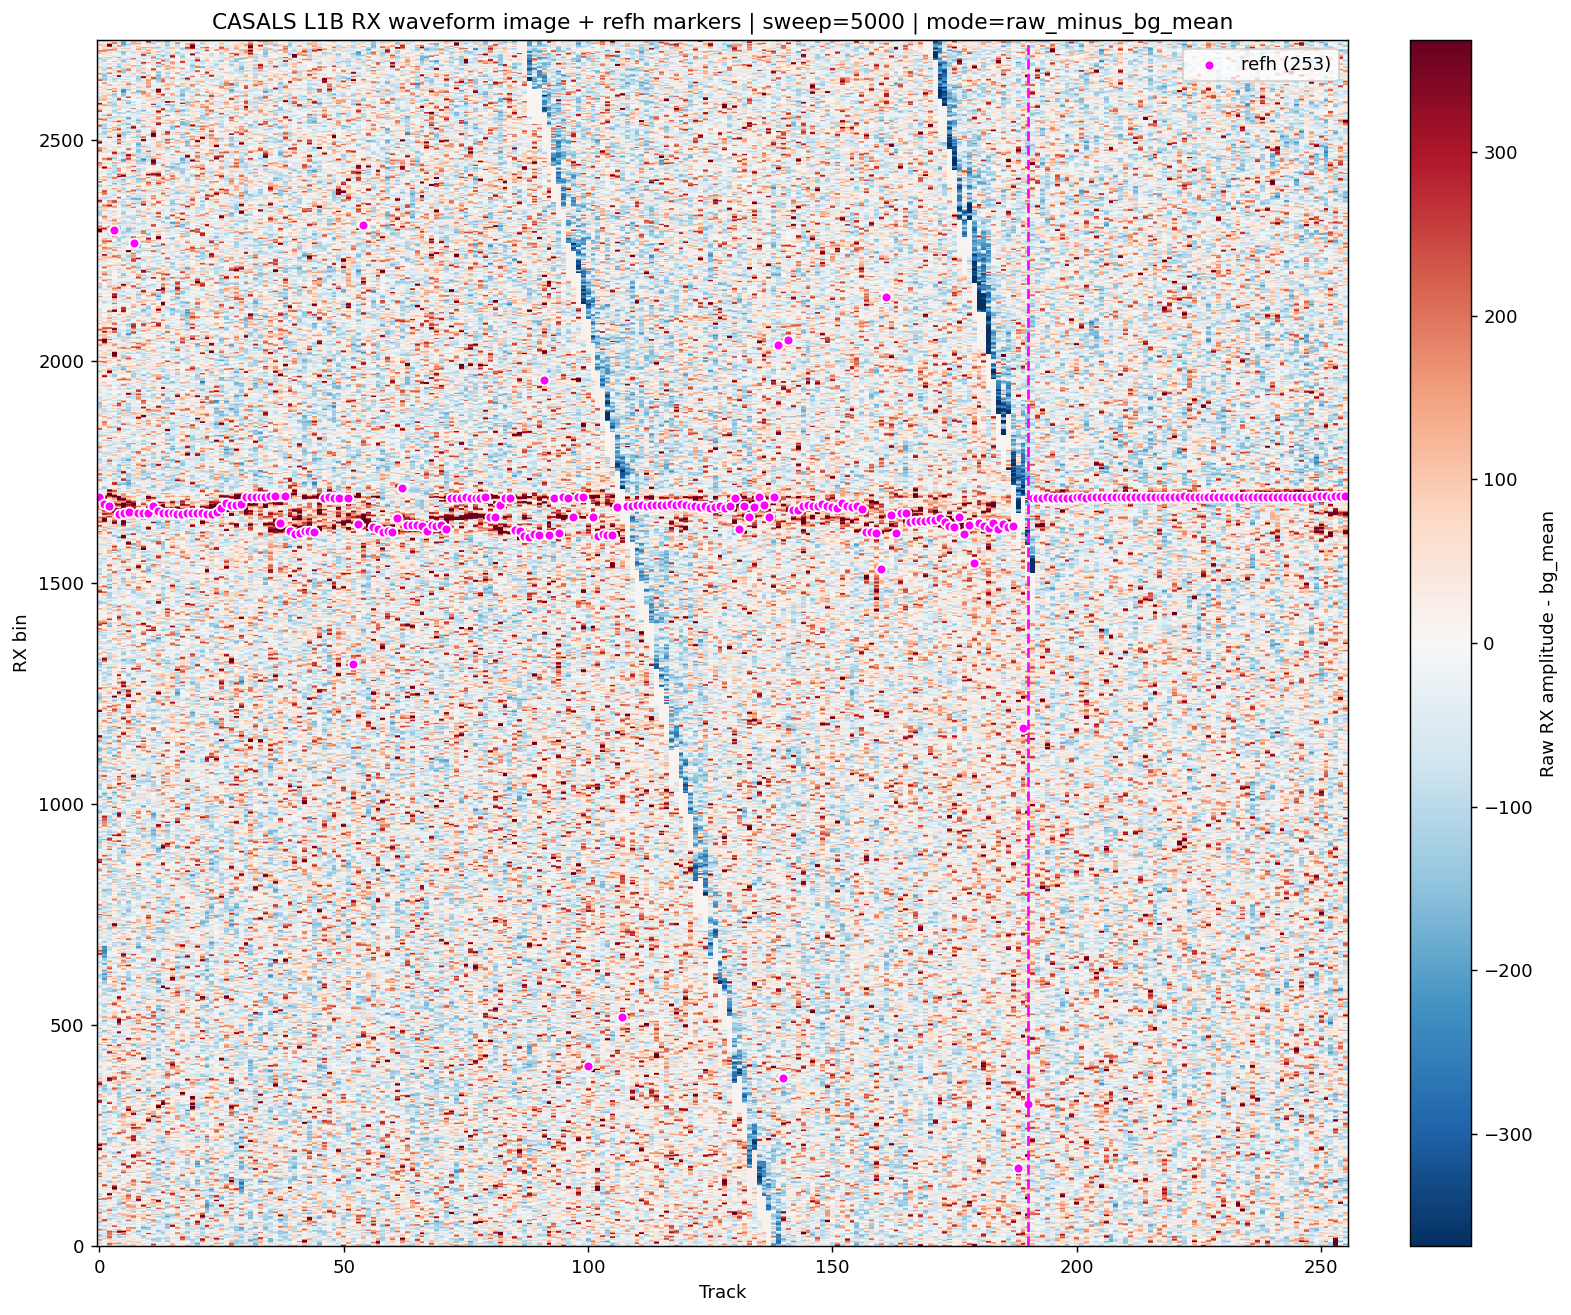

'\nprint(f"refh markers shown for {refh_bin_indices.size} / {n_valid_tracks} tracks.")\n\nfig, ax = plt.subplots(figsize=(12, 10), dpi=FIG_DPI, constrained_layout=True)\n\nim = ax.imshow(\n    rx_image.T,\n    origin="lower",\n    aspect="auto",\n    interpolation="nearest",\n    cmap="RdBu_r",\n    norm=norm,\n    extent=[\n        float(track_axis_values[0]) - 0.5,\n        float(track_axis_values[-1]) + 0.5,\n        float(rx_bins[0]),\n        float(rx_bins[-1]),\n    ],\n)\nif refh_bin_info["status"] == "strict":\n    ax.scatter(\n        [float(TRACK_INDEX)],\n        [float(rx_bins[int(refh_bin_info["bin_index"])])],\n        s=36,\n        c="magenta",\n        edgecolors="black",\n        linewidths=0.5,\n        zorder=5,\n        label="selected track refh",\n    )\n\nax.set_title(\n    f"CASALS L1B RX waveform image + TRACK_INDEX marker | sweep={SWEEP_INDEX}, track={TRACK_INDEX} | mode={RX_IMAGE_VALUE_MODE}"\n)\nax.set_xlabel("Track")\nax.set_ylabel("RX bin")\nax.legend(loc

In [115]:
refh_tracks: list[float] = []
refh_bin_indices: list[int] = []

for track_row, (track_value, record_index) in enumerate(zip(track_axis_values, record_indices_by_track)):
    if int(record_index) < 0:
        continue
    refh_info = strict_refh_bin_from_waveform(
        rx_waveform=rx_matrix_raw[track_row],
        record_index=int(record_index),
        explicit_refh_bin=explicit_refh_bin,
        explicit_refh_bin_path=explicit_refh_bin_path,
        refh_amp=refh_amp,
    )
    if refh_info["status"] == "strict":
        refh_tracks.append(float(track_value))
        refh_bin_indices.append(int(refh_info["bin_index"]))

refh_tracks = np.asarray(refh_tracks, dtype=np.float64)
refh_bin_indices = np.asarray(refh_bin_indices, dtype=np.int64)
n_valid_tracks = int(np.count_nonzero(record_indices_by_track >= 0))

fig, ax = plt.subplots(figsize=(12, 10), dpi=FIG_DPI, constrained_layout=True)

im = ax.imshow(
    rx_image.T,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    norm=norm,
    extent=[
        float(track_axis_values[0]) - 0.5,
        float(track_axis_values[-1]) + 0.5,
        float(rx_bins[0]),
        float(rx_bins[-1]),
    ],
)

if refh_bin_indices.size > 0:
    ax.scatter(
        refh_tracks,
        rx_bins[refh_bin_indices],
        s=30,
        c="magenta",
        edgecolors="white",
        linewidths=1.0,
        alpha=1.0,
        label=f"refh ({refh_bin_indices.size})",
    )
    ax.legend(loc="upper right")

ax.set_title(
    f"CASALS L1B RX waveform image + refh markers | sweep={SWEEP_INDEX} | mode={RX_IMAGE_VALUE_MODE}"
)
ax.set_xlabel("Track")
ax.set_ylabel("RX bin")
fig.colorbar(im, ax=ax, label=colorbar_label)

ax.axvline(float(TRACK_INDEX), color=TRACK_COLOR, linestyle="--", linewidth=1.5, label=f"TRACK_INDEX={TRACK_INDEX}")
plt.show()

'''
print(f"refh markers shown for {refh_bin_indices.size} / {n_valid_tracks} tracks.")

fig, ax = plt.subplots(figsize=(12, 10), dpi=FIG_DPI, constrained_layout=True)

im = ax.imshow(
    rx_image.T,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    norm=norm,
    extent=[
        float(track_axis_values[0]) - 0.5,
        float(track_axis_values[-1]) + 0.5,
        float(rx_bins[0]),
        float(rx_bins[-1]),
    ],
)
if refh_bin_info["status"] == "strict":
    ax.scatter(
        [float(TRACK_INDEX)],
        [float(rx_bins[int(refh_bin_info["bin_index"])])],
        s=36,
        c="magenta",
        edgecolors="black",
        linewidths=0.5,
        zorder=5,
        label="selected track refh",
    )

ax.set_title(
    f"CASALS L1B RX waveform image + TRACK_INDEX marker | sweep={SWEEP_INDEX}, track={TRACK_INDEX} | mode={RX_IMAGE_VALUE_MODE}"
)
ax.set_xlabel("Track")
ax.set_ylabel("RX bin")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label=colorbar_label)

plt.show()
'''


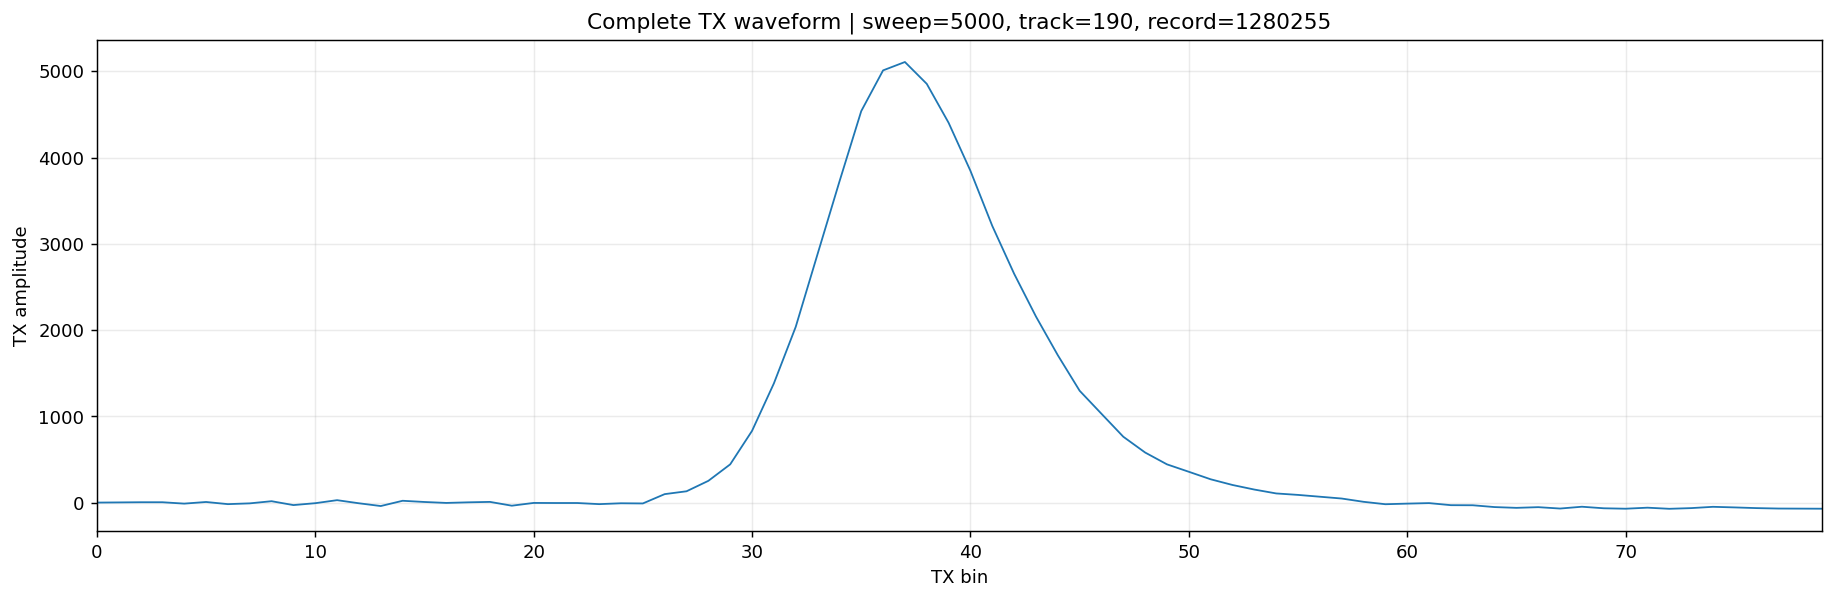

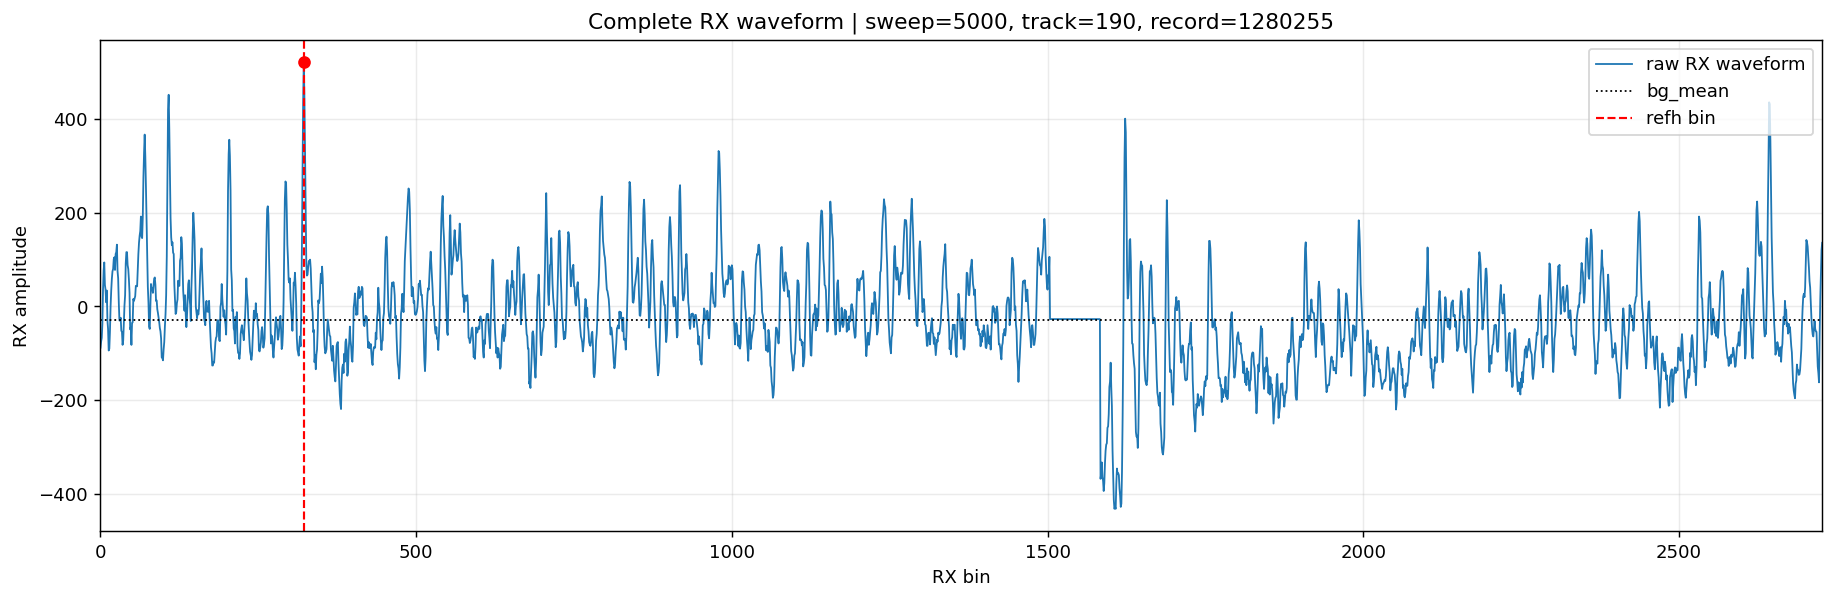

In [116]:
fig, ax = plt.subplots(figsize=(14, 4.5), dpi=FIG_DPI, constrained_layout=True)
ax.plot(tx_bins, tx_waveform, linewidth=1.0)
ax.set_title(f"Complete TX waveform | sweep={SWEEP_INDEX}, track={TRACK_INDEX}, record={record_index}")
ax.set_xlabel("TX bin")
ax.set_ylabel("TX amplitude")
ax.grid(alpha=0.25)
ax.set_xlim(float(tx_bins[0]), float(tx_bins[-1]))
plt.show()


fig, ax = plt.subplots(figsize=(14, 4.5), dpi=FIG_DPI, constrained_layout=True)
ax.plot(rx_bins, rx_waveform, linewidth=1.0, label="raw RX waveform")

if bg_mean is not None and np.isfinite(safe_numeric(bg_mean[record_index])):
    ax.axhline(float(bg_mean[record_index]), color="black", linestyle=":", linewidth=1.0, label="bg_mean")

if refh_bin_info["status"] == "strict":
    bin_index = int(refh_bin_info["bin_index"])
    refh_x = rx_bins[bin_index]
    refh_y = rx_waveform[bin_index]
    ax.axvline(refh_x, color="red", linestyle="--", linewidth=1.2, label="refh bin")
    ax.scatter([refh_x], [refh_y], color="red", s=36, zorder=5)

ax.set_title(f"Complete RX waveform | sweep={SWEEP_INDEX}, track={TRACK_INDEX}, record={record_index}")
ax.set_xlabel("RX bin")
ax.set_ylabel("RX amplitude")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
ax.set_xlim(float(rx_bins[0]), float(rx_bins[-1]))
plt.show()
